DATASET LOADED SUCCESSFULLY

Dataset Shape:
(541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

First 5 Rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0

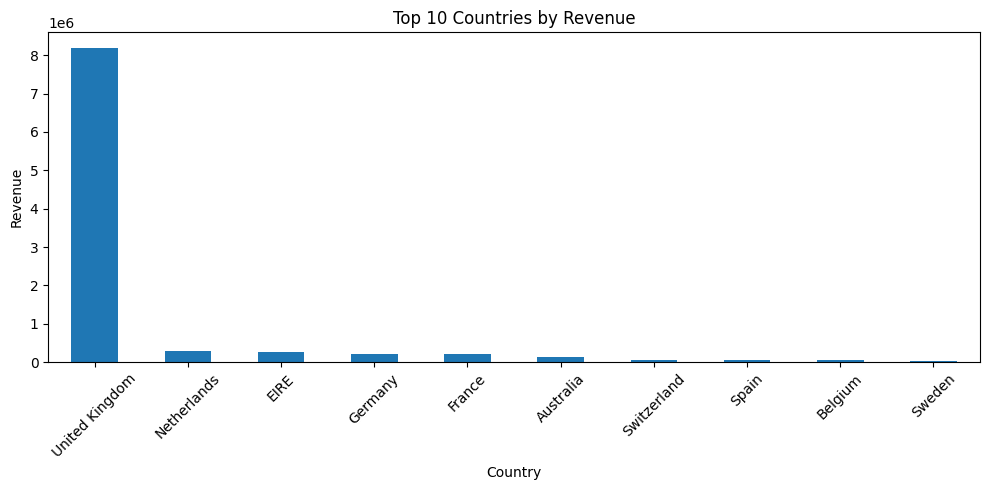

In [2]:
# ==========================================
# CUSTOMER LIFETIME VALUE PROJECT
# PHASE 1: DATA UNDERSTANDING
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Load Dataset
df = pd.read_excel("../data/Online Retail.xlsx")

print("=" * 50)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 50)

# ------------------------------------------
# Basic Information
# ------------------------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

# ------------------------------------------
# First 5 Rows
# ------------------------------------------

print("\nFirst 5 Rows:")
print(df.head())

# ------------------------------------------
# Missing Values
# ------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df)) * 100)

# ------------------------------------------
# Duplicate Records
# ------------------------------------------

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# ------------------------------------------
# Statistical Summary
# ------------------------------------------

print("\nNumerical Summary:")
print(df.describe())

# ------------------------------------------
# Unique Counts
# ------------------------------------------

print("\nUnique Customers:")
print(df["CustomerID"].nunique())

print("\nUnique Products:")
print(df["StockCode"].nunique())

print("\nUnique Countries:")
print(df["Country"].nunique())

# ------------------------------------------
# Feature Engineering
# Revenue = Quantity × UnitPrice
# ------------------------------------------

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# ------------------------------------------
# Business KPIs
# ------------------------------------------

print("\nTotal Revenue:")
print(round(df["Revenue"].sum(), 2))

print("\nTotal Transactions:")
print(df["InvoiceNo"].nunique())

print("\nTotal Customers:")
print(df["CustomerID"].nunique())

print("\nTotal Products:")
print(df["StockCode"].nunique())

# ------------------------------------------
# Top 10 Countries by Revenue
# ------------------------------------------

top_countries = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("\nTop 10 Countries by Revenue:")
print(top_countries)

# ------------------------------------------
# Visualization
# ------------------------------------------

plt.figure(figsize=(10,5))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()